In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import textwrap
import math
import scipy
import scipy.stats as stats
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from datetime import datetime, timedelta
from collections import defaultdict

IBTrACS_path = 'IBTrACS.since1980.v04r01.nc'
IBTrACS_ds = xr.open_dataset(IBTrACS_path).load()

#SHIPS_path = 'atlantic_1982_2023_sat_ts_7day.txt'

### auxiliary methods

In [3]:
'''
"to_datetime" converts a numpy datetime64 object (dtype of IBTrACS and CERES) to a python datetime object
(dtype of time in generated database).

Input:
  date - a np.datetime64 object
Output:
  DATE - a python datetime object
      
Source: https://gist.github.com/blaylockbk/1677b446bc741ee2db3e943ab7e4cabd?permalink_comment_id=3775327
'''
def to_datetime(date):
    timestamp = int((date - np.datetime64('1970-01-01T00:00:00'))
                 / np.timedelta64(1, 's'))
    return datetime.utcfromtimestamp(timestamp)


'''
"to_local_time" converts the IBTrACS time values for a storm (originally UTC time) into its local time.

Input:
  time_values - IBrACS time data
  longitude - IBTrACS storm longitude
Output:
  lt - local time data as numpy datetime64 object
  
'''
def to_local_time(time_values, longitude):
    datetimes = to_datetime(time_values)
    
    # convert to longitude west if needed
    if longitude > 180:
        longitude = longitude - 360
        lt = datetimes - timedelta(hours=int(longitude/15))
    else:
        lt = datetimes + timedelta(hours=int(longitude/15))
    
    return np.datetime64(lt)

In [4]:
def sort_genesis(num_blocks, genesis):
    block = 0
    
    # time blocks: 12am-6am, 6am-12pm, 12pm-6pm, 6pm-12am
    if genesis <= 12 and genesis > 6:
        block = 1;
    elif genesis <= 18 and genesis > 12:
        block = 2;
    elif genesis > 18 or genesis == 0:
        block = 3;
            
    return block

### generate RI split

In [ ]:
'''
Returns only storms categorized as either RI vs. non-RI.

Dataset is specified by sindices and basin byte string name. If all basins are desired, enter 'all' instead of basin byte string.
All TCs whose genesis record is the first record itself are removed.
'''

def generate_RI_split(sindices, basin, nature, duration_thresh, isRI):
    RIstormIdx = [] # stores indices of IBTrACS storms that fit RI category
        # for specified basin, indices will NOT be the same as raw IBTrACS dataset
        # indices will be the same as basin dataset
    
    count = 0
    if basin != 'all':
        basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
    else:
        basin_ds = IBTrACS_ds
    
    num_storms = basin_ds['storm'].size
    sindices = np.arange(1,num_storms)
    
    # append genesis times to histogram
    for storm_index in sindices:
        
        Ivals = []
        otimes = [] # times associated with each dIdt point
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
    
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue
        
        # find intensities
        mask = ~np.isnan(storm_data['wmo_wind'])
        intensities = storm_data['wmo_wind'][mask].values
        
        # find times
        time_clean_raw = storm_data['time'][mask].values
        time_clean = [to_datetime(time) for time in time_clean_raw] # numpy date object to python datetime
        if len(time_clean) == 0:
            continue

        # test to make sure storms are distinct
        #if storm_index < 10:
        #    print(f"coords: {storm_data['lon'][0]}")
        
        # filter out storms lasting under X hours
        storm_duration = (time_clean[len(time_clean)-1] - time_clean[0]).total_seconds()/3600

        if storm_duration < duration_thresh:
            continue
                
        assert len(intensities) == len(time_clean)

        # find dI/dt
        for i in range(len(intensities)):
            if storm_data['nature'][mask].values[i] != nature: # restrict storm intensity
                continue
            # centered difference method for finding dI/dt
            Ivals.append(intensities[i])
            otimes.append(time_clean[i])
            #otimes.append(time_clean[i].hour)

        if len(Ivals) == 0:
            continue

        # convert to m/s (IBTrACS wind speed is in kts)
        otimes = np.array(otimes)
        Ivals = np.array(Ivals)/2.2369

        
        # turn into pandas df
        tempDict = {'times': otimes, 'Ivals': Ivals}
        df = pd.DataFrame(tempDict)

        # create column of 24 hours earlier to find RI
        #df['prev_24hr'] = df['Ivals'].shift(4)
        prev_24hr = []
        for t in range(len(df)):
            twenty_four_hours = np.timedelta64(24, 'h')
            day_before_time = df['times'][t] - twenty_four_hours
            day_before_row = df.loc[df['times'] == day_before_time]
            if len(day_before_row) == 1:
                prev_24hr.append(day_before_row['Ivals'].item())
            else:
                prev_24hr.append(float('nan'))
        #print(f"prev_24hr: {prev_24hr}")
        df['prev_24hr'] = prev_24hr

        # check RI threshold
        if isRI == 0:
            if (df['Ivals']-df['prev_24hr'] <= 18).all():
                RIstormIdx.append(storm_index)
        elif (df['Ivals']-df['prev_24hr'] >= isRI).any():
            RIstormIdx.append(storm_index)

        count += 1
        
        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")
        
        #print(df)
    return RIstormIdx, count

### generate dI/dt data

In [ ]:
'''
FORWARD DIFFERENCE (t+1) - t

Returns dIdt (list of delta intensities between each 3 hour interval) and ltimes (list of hours associated with each delta).
Dataset is specified by sindices and basin byte string name. If all basins are desired, enter 'all' instead of basin byte string.
'''

def intensities_fwd_diff(sindices, basin, nature, duration_thresh):
    dIdt = [] # dt = 3 hours
    Ivals = []
    ltimes = [] # local times associated with each dIdt point
    
    count = 0
    
    if basin != 'all':
        basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
    else:
        basin_ds = IBTrACS_ds

    num_storms = basin_ds['storm'].size
    #sindices = np.arange(1,num_storms)
    
    # append genesis times to histogram
    for storm_index in sindices:
        temp_dIdt = [] # dt = 3 hours
        temp_Ivals = []
        temp_ltimes = []
        
        # ---- Find First Record Time
        # query storm data once it turns into TC
        storm_data = basin_ds.isel(storm=storm_index) # first record
    
        # find storm longitude for local time conversion
        if np.isnan(storm_data['lon']).all():
            continue
        
        # find intensities
        mask = ~np.isnan(storm_data['wmo_wind'])
        intensities = storm_data['wmo_wind'][mask].values
        
        # find times
        time_clean = storm_data['time'][mask].values
        if len(time_clean) == 0:
            continue
        longitude = storm_data['lon'][0]
        local_times = [to_local_time(time, longitude) for time in time_clean]
        times = [to_datetime(time) for time in local_times]

        # filter out storms lasting under X hours
        storm_duration = (times[len(times)-1] - times[0]).total_seconds()/3600

        if storm_duration < duration_thresh:
            continue
        
        # find dI/dt
        assert len(intensities) == len(times)
        for i in range(len(intensities)-1):
            #print("i:",i)
            if storm_data['nature'][mask].values[i] != nature: # restrict storm intensity
                continue
            # centered difference method for finding dI/dt
            delta = (times[i+1]-times[i]).total_seconds()/3600
            accel = (intensities[i+1]-intensities[i])/delta
            if (accel/2.2369) > 3.5:
                    print(f"unusually high acceleration: storm {storm_index}, accel: {accel/2.2369}")
            temp_dIdt.append(accel)
            temp_Ivals.append(intensities[i+1])
            temp_ltimes.append(times[i+1].hour) # basically remove first data point from times

        if len(temp_dIdt) == 0:
            continue

        # filter out weakening accelerations
        max_idx = np.argmax(temp_Ivals)
        #print(f"storm: {storm_index}, max_idx: {max_idx}")
        dIdt.extend(temp_dIdt[:max_idx+1])
        ltimes.extend(temp_ltimes[:max_idx+1])
        Ivals.extend(temp_Ivals[:max_idx+1])

        count += 1
        
        if count % 1000 == 0:
            print(count, "/", len(sindices), "databases loaded")

    #print(dIdt)
    # convert to m/s (IBTrACS wind speed is in kts)
    dIdt = np.array(dIdt)/2.2369
    ltimes = np.array(ltimes)
    Ivals = np.array(Ivals)/2.2369

    tempDict = {'dIdt': dIdt, 'ltimes': ltimes, 'Ivals': Ivals}
    df = pd.DataFrame(tempDict)
    
    return df, count

### get dI/dt data

In [242]:
sindices = np.arange(2221,4787)
basin = b'SP'
nature = b'TS'
duration_thresh = 0
isRI = 26

RIstorms, count = generate_RI_split(sindices, basin, nature, duration_thresh, isRI)
print(f"# storms: {count}")
print(f"# RI storms: {len(RIstorms)}")
#print(RIstorms)
#nonRIstorms, count = generate_RI_split(basin, nature, duration_thresh, 0)

# storms: 439
# RI storms: 3


In [243]:
sindices = RIstorms
duration_thresh = 0

df, count = intensities_fwd_diff(sindices, basin, nature, duration_thresh)
df

,dIdt,ltimes,Ivals
0,0.000000,9,8.940945
1,0.000000,15,8.940945
2,0.000000,21,8.940945
3,0.000000,3,8.940945
4,0.745079,9,13.411417
...,...,...,...
83,1.117618,10,29.058071
84,2.235236,16,42.469486
85,0.882330,18,44.704723
86,0.644780,22,46.939960


## Plots

### violin plots

[None, None, None, None]

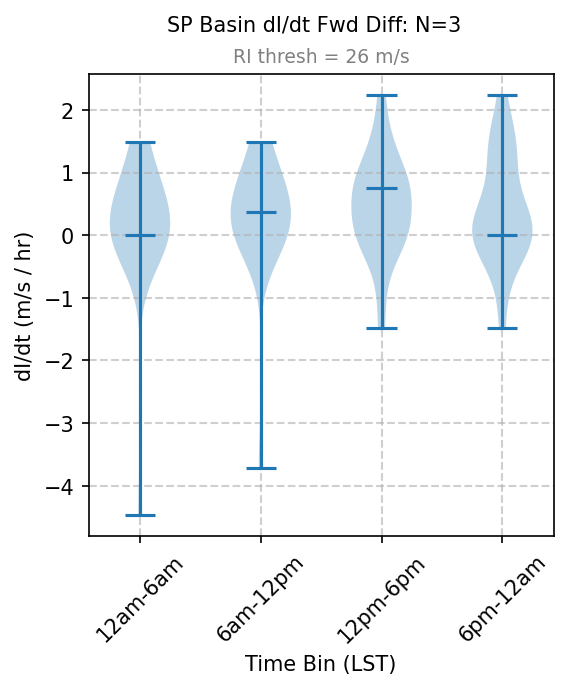

In [244]:
#------------------------ Figure -----------------------------
num_blocks = 4

bin1 = []
bin2 = []
bin3 = []
bin4 = []

for j in range(len(df['dIdt'])):
    block = sort_genesis(num_blocks, df['ltimes'][j])
    if block == 0:
        bin1.append(df['dIdt'][j])
    elif block == 1:
        bin2.append(df['dIdt'][j])
    elif block == 2:
        bin3.append(df['dIdt'][j])
    else:
        bin4.append(df['dIdt'][j])

fig, ax = plt.subplots(figsize=(4,4), dpi=150)

pos = np.arange(num_blocks)
data =[bin1, bin2, bin3, bin4]
cat = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']

ax.violinplot(data, pos, showmeans=False, showmedians=True)
ax.set_ylabel('dI/dt (m/s / hr)')
ax.set_xlabel('Time Bin (LST)')
ax.grid(alpha=0.6, linestyle='--', linewidth=1, which='both')
#ax.set_title(f"All Basins dI/dt per LST bin: N={count}", fontsize=10)
if ctr == 1:
    fig.suptitle(f"{basin.decode('utf-8')} Basin dI/dt Ctr Diff: N={count}", fontsize=10)
else:
    fig.suptitle(f"{basin.decode('utf-8')} Basin dI/dt Fwd Diff: N={count}", fontsize=10)

ax.set_title(f"RI thresh = {isRI} m/s", fontsize=9, color='gray')

ax.set_xticks(pos.T)
ax.set_xticklabels(cat)
plt.setp(ax.get_xticklabels(), rotation=45)

### histograms

[None, None, None, None]

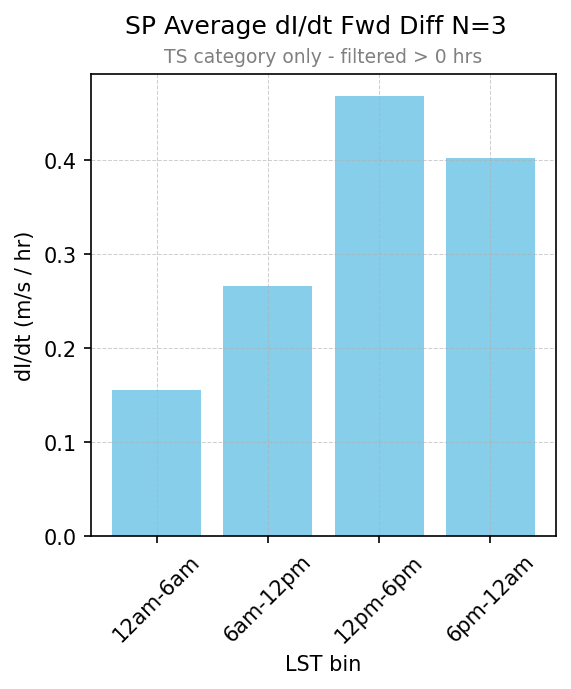

In [245]:
# ------------------------ Find Average ------------------------
bin1 = []
bin2 = []
bin3 = []
bin4 = []

for j in range(len(df['dIdt'])):
    block = sort_genesis(num_blocks, df['ltimes'][j])
    if block == 0:
        bin1.append(df['dIdt'][j])
    elif block == 1:
        bin2.append(df['dIdt'][j])
    elif block == 2:
        bin3.append(df['dIdt'][j])
    else:
        bin4.append(df['dIdt'][j])

bin1 = np.array(bin1)
bin2 = np.array(bin2)
bin3 = np.array(bin3)
bin4 = np.array(bin4)

dIdt_hist = np.array([bin1.mean(), bin2.mean(), bin3.mean(), bin4.mean()])
errors = np.array([bin1.std(), bin2.std(), bin3.std(), bin4.std()])

cat = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']

#------------------------ Figure -----------------------------
fig, ax = plt.subplots(figsize=(4,4), dpi=150)
ax.bar(cat, dIdt_hist, capsize=3, color='skyblue')
#ax.invert_yaxis()
ax.set_xlabel('LST bin')
ax.set_ylabel('dI/dt (m/s / hr)')
#ax.set_ylabel('dI/dt (mb/hr)')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

if basin == 'all':
    fig.suptitle(f"All Basins Average dI/dt N={count}")
else:
    if ctr == 1:
        fig.suptitle(f"{basin.decode('utf-8')} Average dI/dt Ctr Diff N={count}")
    else:
        fig.suptitle(f"{basin.decode('utf-8')} Average dI/dt Fwd Diff N={count}")

ax.set_title(f"{nature.decode('utf-8')} category only - filtered > {duration_thresh} hrs", fontsize=9, color='gray')

plt.setp(ax.get_xticklabels(), rotation=45)